In [2]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Robert Swain

In [4]:
sample_size = 100
eligible_population = make_array(0.26, 0.74)

In [20]:
sample_proportions(sample_size, eligible_population)

array([ 0.21,  0.79])

In [22]:
def one_simulated_count():
    return sample_size * sample_proportions(sample_size, eligible_population).item(0)

In [31]:
one_simulated_count()

22.0

In [32]:
# Crushed ICE: create an array called counts and add 10,000 simulated counts to it
counts = make_array()
repetitions = 10000
for i in np.arange(repetitions):
    counts = np.append(counts, one_simulated_count())

In [33]:
counts

array([ 26.,  23.,  27., ...,  24.,  27.,  22.])

In [35]:
Table().with_column('Counts in a random sample', counts).sort(0)

Counts in a random sample
10
11
12
12
12
13
13
13
13
13


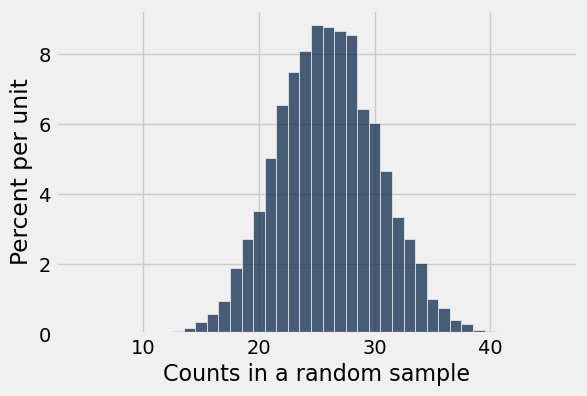

In [37]:
Table().with_column('Counts in a random sample', counts).hist(bins=np.arange(4.5, 45.6, 1))

In [39]:
np.count_nonzero(counts == 8)

0

In [40]:
np.count_nonzero(counts <= 8)

0

# Jury Selection in Alameda County

In [41]:
jury = Table().with_columns(
    'Ethnicity', make_array('Asian/PI', 'Black/AA', 'Caucasian', 'Hispanic', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.54, 0.12, 0.01),
    'Panels', make_array(0.26, 0.08, 0.54, 0.08, 0.04)
)
jury

Ethnicity,Eligible,Panels
Asian/PI,0.15,0.26
Black/AA,0.18,0.08
Caucasian,0.54,0.54
Hispanic,0.12,0.08
Other,0.01,0.04


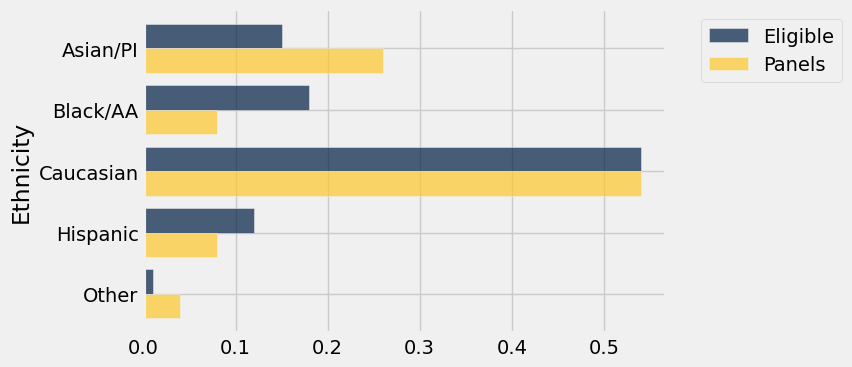

In [42]:
jury.barh('Ethnicity')

In [43]:
# Crushed ICE: There were 1,453 people on juries during the study.
# Using the proportions of eligible jurors and sample_proportions, simluate picking 1,453 jurors
jury.column('Eligible')

array([ 0.15,  0.18,  0.54,  0.12,  0.01])

In [50]:
model = jury.column('Eligible')
simulated = sample_proportions(1453, model)
simulated

array([ 0.13833448,  0.17894012,  0.56503785,  0.10736407,  0.01032347])

In [51]:
jury_with_simulated = jury.with_column('Simluated', simulated)
jury_with_simulated

Ethnicity,Eligible,Panels,Simluated
Asian/PI,0.15,0.26,0.138334
Black/AA,0.18,0.08,0.17894
Caucasian,0.54,0.54,0.565038
Hispanic,0.12,0.08,0.107364
Other,0.01,0.04,0.0103235


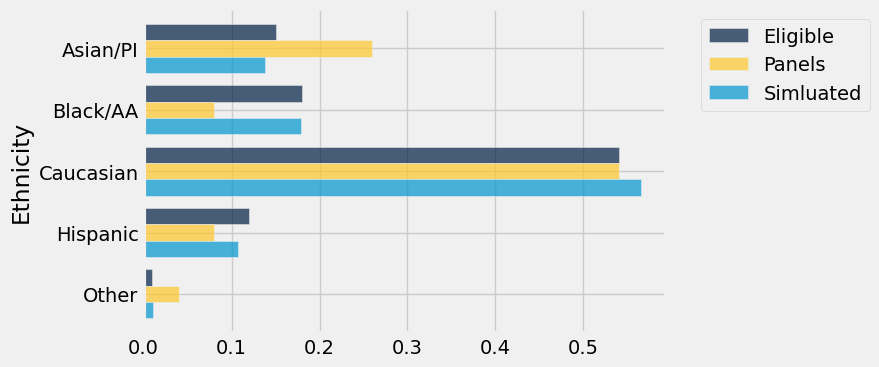

In [52]:
jury_with_simulated.barh('Ethnicity')

In [53]:
# There aren't just two things to compare! Goal: make *one number* to represent the differences
# We need a new statistic to measure the difference between the distributions!

In [56]:
diffs = jury.column('Panels') - jury.column('Eligible')
jury_with_difference = jury.with_column('Difference', diffs)
jury_with_difference

Ethnicity,Eligible,Panels,Difference
Asian/PI,0.15,0.26,0.11
Black/AA,0.18,0.08,-0.1
Caucasian,0.54,0.54,0
Hispanic,0.12,0.08,-0.04
Other,0.01,0.04,0.03


In [58]:
sum(jury_with_difference.where('Difference', are.above(0)).column('Difference'))

0.14000000000000001

In [63]:
sum(abs(jury_with_difference.column('Difference'))) / 2

0.14000000000000001

In [65]:
def tvd(dist1, dist2):
    return sum(abs(dist1 - dist2)) / 2

In [85]:
observed_tvd = tvd(jury.column('Panels'), jury.column('Eligible'))
observed_tvd

0.14000000000000001

In [86]:
tvd(sample_proportions(1453, model), jury.column('Eligible'))

0.014487267721954597

In [88]:
def simulated_tvd():
    return tvd(sample_proportions(1453, model), jury.column('Eligible'))

tvds = make_array()

# Crushed ICE: simulate 10,000 tvds into the tvds array
num_simulations = 10000
for i in np.arange(num_simulations):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

In [89]:
len(tvds)

10000

In [90]:
tvds

array([ 0.01653131,  0.01549209,  0.01318651, ...,  0.0203097 ,
        0.01328975,  0.01434962])

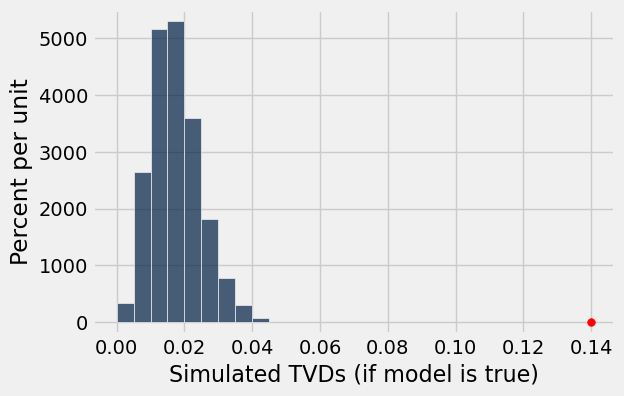

In [93]:
title = 'Simulated TVDs (if model is true)'
bins = np.arange(0, 0.05, 0.005)

Table().with_column(title, tvds).hist(bins=bins)

# Plotting the observed TVD--ignore this code!
plt.ylim(-2, 55)
plt.scatter(observed_tvd, 0, color='red', s=30);

In [94]:
np.count_nonzero(tvds >= 0.14)

0

# Mendel

In [2]:
705/929

0.7588805166846071

In [7]:
observed_statistic = abs(100 * (705 / 929) - 75)
observed_statistic

0.8880516684607045

In [8]:
# Crushed ICE: use Mendel's model (75% purple, 25% white) to simulate a garden of 929 pea plants,
# and extract the proportion that were purple
# Hint: use sample_proportions

In [11]:
mendel_proportions = make_array(0.75, 0.25)

sample_proportions(929, mendel_proportions)

array([ 0.75780409,  0.24219591])

In [20]:
sample_proportion_purple = sample_proportions(929, mendel_proportions).item(0)
abs(100 * sample_proportion_purple - 75)

1.7491926803014053

In [21]:
# Crushed ICE: make a function called one_simulated_distance to run a single simulation
# and calculate the distance from Mendel's model
def one_simulated_distance():
    sample_proportion_purple = sample_proportions(929, mendel_proportions).item(0)
    return abs(100 * sample_proportion_purple - 75)

In [25]:
one_simulated_distance()

1.8568353067814911

In [26]:
repetitions = 10000
distances = make_array()
for i in np.arange(repetitions):
    distances = np.append(distances, one_simulated_distance())

In [27]:
distances

array([ 0.45748116,  1.85683531,  0.34983854, ...,  1.04951561,
        0.29601722,  0.40365985])

In [29]:
dists = Table().with_column(
    'Distance between Sample % and 75%', distances
)
dists

Distance between Sample % and 75%
0.457481
1.85684
0.349839
0.080732
0.457481
2.87944
3.68676
1.37244
1.10334
2.61033


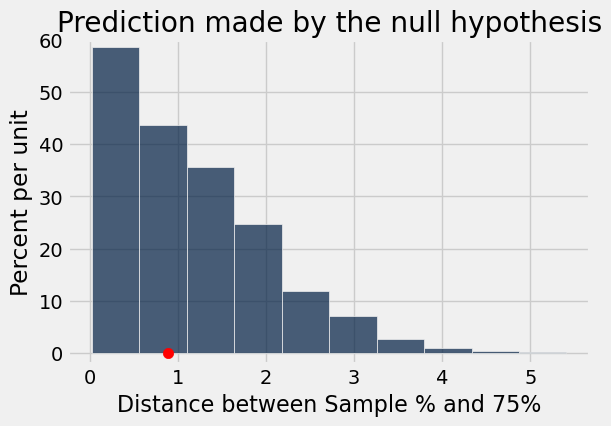

In [32]:
dists.hist()
plt.title('Prediction made by the null hypothesis')

plt.ylim(-0.02, 0.6)
plt.scatter(observed_statistic, 0, color='red', s=55);

In [36]:
np.count_nonzero(distances >= observed_statistic) / repetitions

0.5515

In [37]:
# ^ a p-value

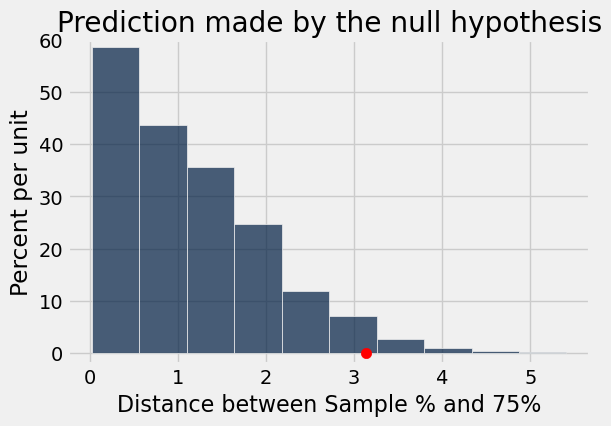

In [38]:
different_observed_statistic = 3.14

dists.hist()
plt.title('Prediction made by the null hypothesis')

plt.ylim(-0.02, 0.6)
plt.scatter(different_observed_statistic, 0, color='red', s=55);

In [39]:
np.count_nonzero(distances >= different_observed_statistic) / repetitions

0.0273

# Midterm Scores

In [40]:
scores = Table.read_table('data/scores_by_section.csv')
scores

Section,Midterm
1,22
2,12
2,23
2,14
1,20
3,25
4,19
1,24
5,8
6,14


In [44]:
# Crushed ICE: get the average midterm scores by section
scores.group('Section', np.average).show()

Section,Midterm average
1,15.5938
2,15.125
3,13.6667
4,14.7667
5,17.4545
6,15.0312
7,16.625
8,16.3103
9,14.5667
10,15.2353


In [46]:
scores.group('Section').show()

Section,count
1,32
2,32
3,27
4,30
5,33
6,32
7,24
8,29
9,30
10,34


In [48]:
section_3_average = scores.group('Section', np.average).column('Midterm average').item(2)
section_3_size = scores.group('Section').column('count').item(2)

In [51]:
# Crushed ICE: simulate a section with the same size as Section 3 by picking random students,
# and get the average score.
# Don't allow any students to be included multiple times!
random_section = scores.sample(section_3_size, with_replacement=False)
random_section

Section,Midterm
4,7
1,8
6,14
6,10
2,21
4,13
3,23
8,17
2,17
6,10


In [53]:
np.average(random_section.column('Midterm'))

13.962962962962964

In [62]:
np.average(scores.sample(section_3_size, with_replacement=False).column('Midterm'))

15.037037037037036

In [63]:
def one_simulated_average():
    return np.average(scores.sample(section_3_size, with_replacement=False).column('Midterm'))

one_simulated_average()

15.148148148148149

In [64]:
# Crushed ICE: simulate 10,000 averages into an array called sample_averages
simulations = 10000
sample_averages = make_array()
for i in np.arange(simulations):
    sample_averages = np.append(sample_averages, one_simulated_average())

In [65]:
sample_averages

array([ 15.92592593,  13.48148148,  15.33333333, ...,  14.81481481,
        15.11111111,  13.88888889])

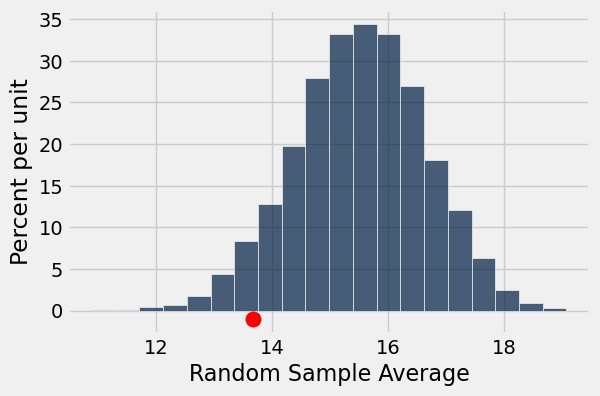

In [70]:
averages_tbl = Table().with_column('Random Sample Average', sample_averages)
averages_tbl.hist(bins=20)
plt.scatter(section_3_average, -0.01, color='red', s=120);

In [72]:
np.count_nonzero(sample_averages <= section_3_average) / simulations

0.0559

In [73]:
# What would you do if you were the teacher?

---

# Fish Diet

In [3]:
diet = Table.read_table('data/fish-diet.csv')
diet

Diet,Cancer
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes


In [5]:
diet.sample(10)

Diet,Cancer
Small,No
Moderate,No
Small,No
Moderate,No
Small,No
Moderate,No
Moderate,No
Large,No
Large,No
Moderate,No


In [6]:
diet.group('Diet')

Diet,count
Large,549
Moderate,2978
Never,124
Small,2621


In [7]:
diet.group(make_array('Diet', 'Cancer'))

Diet,Cancer,count
Large,No,507
Large,Yes,42
Moderate,No,2769
Moderate,Yes,209
Never,No,110
Never,Yes,14
Small,No,2420
Small,Yes,201


In [9]:
diet.pivot('Cancer', 'Diet')

Diet,No,Yes
Large,507,42
Moderate,2769,209
Never,110,14
Small,2420,201


In [10]:
diet2 = diet.pivot('Cancer', 'Diet')
diet2.column('Yes') / (diet2.column('Yes') + diet2.column('No'))

array([ 0.07650273,  0.07018133,  0.11290323,  0.07668829])

In [13]:
sum(diet2.column('Yes')) / diet.num_rows

0.074298469387755098

In [14]:
sample_proportion = sum(diet2.column('Yes')) / diet.num_rows

In [23]:
sample_proportions(110 + 14, make_array(sample_proportion, 1 - sample_proportion))

array([ 0.07258065,  0.92741935])

In [24]:
sample_proportions(110 + 14, make_array(sample_proportion, 1 - sample_proportion)).item(0)

0.04838709677419355

In [25]:
def one_simulated_rate():
    return sample_proportions(110 + 14, make_array(sample_proportion, 1 - sample_proportion)).item(0)

In [27]:
one_simulated_rate()

0.024193548387096774

In [28]:
simulations = 10000
simulated_rates = make_array()
for i in np.arange(simulations):
    simulated_rates = np.append(simulated_rates, one_simulated_rate())

In [29]:
simulated_rates

array([ 0.05645161,  0.11290323,  0.08870968, ...,  0.09677419,
        0.08870968,  0.08064516])

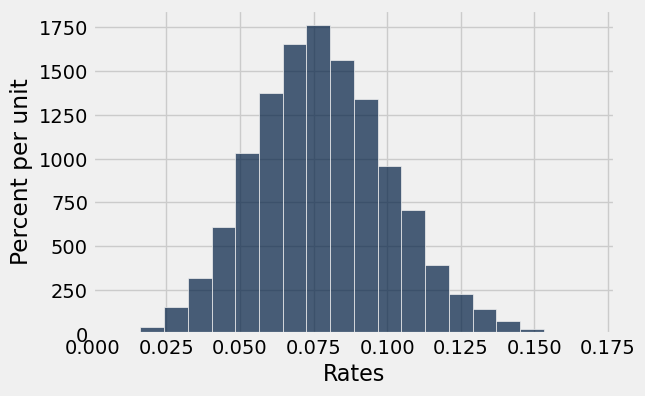

In [32]:
Table().with_column('Rates', simulated_rates).hist(0, bins=20)

In [35]:
np.count_nonzero(simulated_rates >= 0.11290323) / len(simulated_rates)

0.0388

In [ ]:
# Just like Mendel, we had to "guess" a cancer rate here to make our model,
# and that feels a little wrong. We'll see a better way to do this kind of 
# test in the next chapter.

In [36]:
# Let's try to treat this dataset like the Midterm scores example

In [37]:
diet

Diet,Cancer
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes
Never,Yes


In [38]:
def cancer_to_number(yes_or_no):
    if yes_or_no == 'Yes':
        return 1
    else:
        return 0

In [40]:
cancer_to_number('Yes')

1

In [42]:
diet3 = diet.with_column('Cancer As Number', diet.apply(cancer_to_number, 'Cancer'))
diet3

Diet,Cancer,Cancer As Number
Never,Yes,1
Never,Yes,1
Never,Yes,1
Never,Yes,1
Never,Yes,1
Never,Yes,1
Never,Yes,1
Never,Yes,1
Never,Yes,1
Never,Yes,1


In [44]:
random_group = diet3.sample(124, with_replacement=False)
random_group

Diet,Cancer,Cancer As Number
Large,No,0
Moderate,No,0
Moderate,No,0
Moderate,No,0
Moderate,No,0
Moderate,No,0
Moderate,No,0
Small,No,0
Small,No,0
Moderate,No,0


In [46]:
random_group.column('Cancer As Number').mean()

0.032258064516129031

In [47]:
def one_simulated_rate():
    random_group = diet3.sample(124, with_replacement=False)
    return random_group.column('Cancer As Number').mean()

simulations = 10000
simulated_rates = make_array()
for i in np.arange(simulations):
    simulated_rates = np.append(simulated_rates, one_simulated_rate())

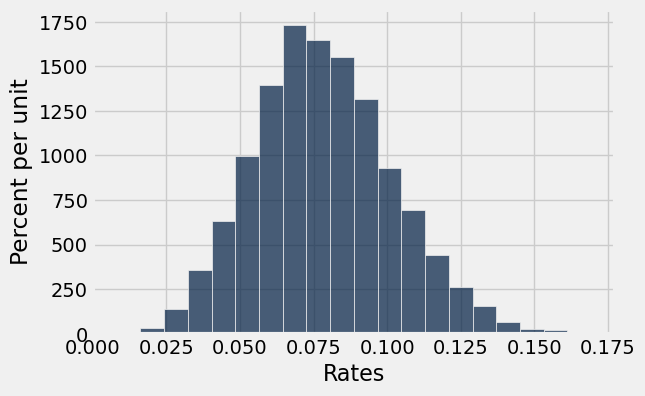

In [48]:
Table().with_column('Rates', simulated_rates).hist(0, bins=20)

In [49]:
np.count_nonzero(simulated_rates >= 0.11290323) / len(simulated_rates)

0.0426

# Titanic

In [50]:
titanic = Table.read_table('data/titanic.csv')
titanic

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,nan,S
6,0,3,"Moran, Mr. James",male,nan,0,0,330877,8.4583,nan,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,nan,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C


In [51]:
# Step 1: get the proportion of women who survived

In [53]:
titanic.where('Survived', are.equal_to(1)).group('Sex')

Sex,count
female,233
male,109


In [54]:
233 / (233 + 109)

0.6812865497076024

In [56]:
titanic.where('Sex', 'female').group('Survived')

Survived,count
0,81
1,233


In [57]:
233 / (233 + 81)

0.7420382165605095

In [58]:
# ^ this is another way of asking the question. Let's go with the first option.

In [59]:
# Step 2: simulate a group of (233 + 109) people under the null hypothesis's model
# (where men & women were equally likely to survive) and get the proportion
# of women survivors.

In [61]:
sample_proportions(233 + 109, make_array(0.5, 0.5))

array([ 0.52046784,  0.47953216])

In [62]:
# Step 3: make a function to create a random sample and get the surivor rate
# Run your function 10,000 times, saving the rate each time

In [63]:
def one_simulated_rate():
    return sample_proportions(233 + 109, make_array(0.5, 0.5)).item(1)

simulations = 10000
simulated_rates = make_array()
for i in np.arange(simulations):
    simulated_rates = np.append(simulated_rates, one_simulated_rate())

In [64]:
simulated_rates

array([ 0.47368421,  0.47368421,  0.51754386, ...,  0.51169591,
        0.52046784,  0.4502924 ])

In [65]:
# Step 4: create a histogram of the rates, and see how likely it is to get a rate
# as high as we saw or higher (so also calculate a p-value)

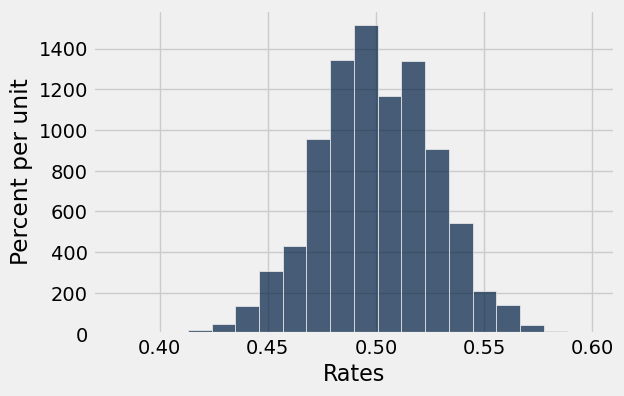

In [66]:
Table().with_column('Rates', simulated_rates).hist(0, bins=20)

In [67]:
np.count_nonzero(simulated_rates >= 0.6812865497076024) / len(simulated_rates)

0.0

In [68]:
# Conclusion: we *reject* the null hypothesis

# Cereal

In [69]:
cereal = Table.read_table('data/cereal.csv')
cereal

name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
100% Bran,N,C,70,4,1,130,10,5,6,280,25,3,1,0.33,68.403
100% Natural Bran,Q,C,120,3,5,15,2,8,8,135,0,3,1,1,33.9837
All-Bran,K,C,70,4,1,260,9,7,5,320,25,3,1,0.33,59.4255
All-Bran with Extra Fiber,K,C,50,4,0,140,14,8,0,330,25,3,1,0.5,93.7049
Almond Delight,R,C,110,2,2,200,1,14,8,-1,25,3,1,0.75,34.3848
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1,0.75,29.5095
Apple Jacks,K,C,110,2,0,125,1,11,14,30,25,2,1,1,33.1741
Basic 4,G,C,130,3,2,210,2,18,8,100,25,3,1.33,0.75,37.0386
Bran Chex,R,C,90,2,1,200,4,15,6,125,25,1,1,0.67,49.1203
Bran Flakes,P,C,90,3,0,210,5,13,5,190,25,3,1,0.67,53.3138


In [72]:
cereal.select('shelf', 'sugars').group('shelf', np.average)

shelf,sugars average
1,4.8
2,9.61905
3,6.52778


In [73]:
cereal.select('shelf', 'sugars').group('shelf')

shelf,count
1,20
2,21
3,36


In [78]:
cereal.sample(21, with_replacement=False).column('sugars').mean()

7.4285714285714288

In [81]:
def one_simulated_average():
    return cereal.sample(21, with_replacement=False).column('sugars').mean()

simulations = 10000
simulated_averages = make_array()
for i in np.arange(simulations):
    simulated_averages = np.append(simulated_averages, one_simulated_average())

In [82]:
simulated_averages

array([ 5.19047619,  6.0952381 ,  6.19047619, ...,  8.04761905,
        6.71428571,  7.57142857])

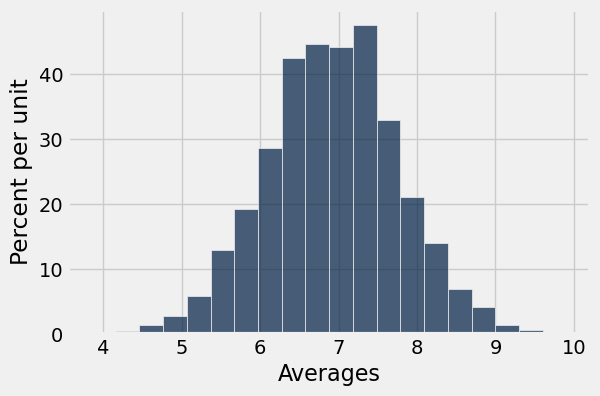

In [85]:
Table().with_column('Averages', simulated_averages).hist(0, bins=20)

In [88]:
np.count_nonzero(simulated_averages >= 9.61905) / len(simulated_averages)

0.0006